# 3 targets: SM, ET and Q

When training I will have 3 losses to optmize upon. Two of them are computed cell by cell, whilst the $ Q $ should be computed over the entire upstream basin cells. 

Now working only with 1 timeseries of discharge per basin. It is better that it comes form the outlet of the basin so that I can compute the combined loss for all the upstream cells. Otherwise some cells would be out and should not partecipate in the computation of the loss. like

loss = sm_et_q_loss (inside basin) + sm_et_loss (outside basin)

It does not make much sense. 

The other idea is to compute before hand the sampling error as we subsample the domain. So that we have a sm + et + err -> q

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import random

from torch import nn

from sklearn.metrics import mean_squared_error
from hython.preprocess import reshape, apply_normalization
from hython.datasets.datasets import LSTMDataset, LSTMDischargeDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, SpaceSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

from hython.utils import missing_location_idx, reconstruct_from_missing, load
from hython.models.lstm import CustomLSTM



# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler
from hython.utils import predict, prepare_for_plotting
from hython.viz import map_bias, map_pbias, map_pearson, map_at_timesteps, ts_compare, plot_sampler

def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(43)

In [876]:
dynamic_names = ["precip", "pet", "temp"]
static_names = [ "distance", "hao"] #, 'TT', 'KsatHorFrac'] 
target_names = [ "q_river"]


outlet_id = "1404" # adige a verona

outlet_lat_lon = [45.44258, 11.00154]


fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"

fn_surr_distance = "adige_distance_to_outlet.nc"
fn_surr_hand = "adige_hand.nc"
fn_surr_hao = "adige_height_above_outlet.nc"

start_date = "2010-01-01"
end_date = "2020-12-31"


timeslice = slice(start_date, end_date)

In [877]:
wflow_model = "adg1km" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

wd = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/models") / wflow_model


fp_d = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_discharge.csv"
fp_meta = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_Adige_surrogate_test_discharge_metadata.csv"

input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / wflow_model
output_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/surrogate/')
model_weigths_path = output_dir_path / "model_weights"
surrogate_input_path = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_inputs")

fp_surr_distance = surrogate_input_path / fn_surr_distance 
fp_surr_hand = surrogate_input_path / fn_surr_hand 
fp_surr_hao = surrogate_input_path / fn_surr_hao

fp_discharge_outlets = input_dir_path / "run_default/output.csv"

In [878]:
ado_dis = pd.read_csv(fp_d)
ado_meta = pd.read_csv(fp_meta)

In [879]:
ado_meta

,id_station,id,geom,country,region,location_site,lat,lon,start_date,end_date,watercourse,height_masl,height_dem,catchm_area,source_id,note_influence
0,ADO_DSC_ITH1_0038,1401,0101000020E610000039CE12094BB326400954BD044041...,Italy,Provincia Autonoma di Bolzano/Bozen,Talfer - Bozen,46.509766,11.350182,2011-01-18,2022-05-26,Talvera - Talfer,287.71,290.2515,NaN,NaN,NaN
1,ADO_DSC_ITH3_0002,1404,0101000020E61000004BAAD7A9C9002640101D867FA6B8...,Italy,Veneto,Adige a Verona,45.442581,11.001539,2010-01-01,2021-07-31,Adige,52.00,58.2245,NaN,NaN,NaN


In [880]:
Q = ado_dis[ado_dis.id_station == ado_meta.set_index("id").loc[int(outlet_id)].id_station]
Q['date'] = pd.to_datetime(Q.date)
Q = Q.sort_values("date")
Q.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4230 entries, 12317275 to 12321504
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_station      4230 non-null   object        
 1   date            4230 non-null   datetime64[ns]
 2   discharge_m3_s  4230 non-null   float64       
 3   quality         4230 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 165.2+ KB


/tmp/ipykernel_1685229/2089033209.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q['date'] = pd.to_datetime(Q.date)


In [881]:
Q = Q.reset_index().drop(["id_station", "quality","index"], axis =1).rename({"discharge_m3_s":"discharge","date":"time"}, axis=1)

In [882]:
Q

,time,discharge
0,2010-01-01,70.70
1,2010-01-02,73.33
2,2010-01-03,71.98
3,2010-01-04,72.70
4,2010-01-05,92.49
...,...,...
4225,2021-07-27,226.56
4226,2021-07-28,227.97
4227,2021-07-29,212.22
4228,2021-07-30,187.02


In [883]:
forcings = xr.open_dataset(input_dir_path / fn_forcings , chunks= {"time":100})
params = xr.open_dataset(input_dir_path / fn_params ,  chunks= {"time":100}).sel(layer=1)
targets = xr.open_dataset(input_dir_path / "run_default" / fn_targets, chunks= {"time":100}).sel(layer=1).isel(lat=slice(None, None, -1))

In [884]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

In [885]:
hand = xr.open_dataset(fp_surr_hand).rename({"band_data":"hand"})

In [886]:
distance = xr.open_dataset(fp_surr_distance).rename({"__xarray_dataarray_variable__":"distance"}) 

In [887]:
hao = xr.open_dataset(fp_surr_hao).rename({"band_data":"hao"})

In [888]:
params["distance"]= (("lat", "lon"), distance.distance.data)

In [889]:
params["hand"]= (("lat", "lon"), hand.hand.data)

In [890]:
params["hao"]= (("lat", "lon"), hao.hao.data)

In [891]:
forcings = forcings[dynamic_names]
params = params[static_names]
targets = targets[target_names] 

In [892]:
#params["distance"] = (1/(params.distance + 1))

In [893]:
# select discharge 
discharge = pd.read_csv(fp_discharge_outlets).filter(regex=f"Q_{outlet_id}|time", axis=1)
discharge['time'] = pd.to_datetime(discharge.time)

In [894]:
# training 

spatial_batch_size = 256
temporal_sampling_size = 250 
seq_length = 360 # days

# model 

hidden_size = 32

model_params={
    "input_size": 3, #number of dynamic predictors - user_input
    "hidden_size": hidden_size, # user_input
    "output_size": len(target_names), # number_target - user_input
    "number_static_predictors": len(static_names), #number of static parameters - user_input 

}

## The used device for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [895]:
remove_lakes = True

if remove_lakes:
    mask_lakes = (targets.mean(dim = "time")[target_names[0]] == 0).astype(np.bool_)
    targets = targets.where(~mask_lakes, np.nan)
    forcings = forcings.where(~mask_lakes, np.nan)
    params = params.where(~mask_lakes, np.nan)


if timeslice:
    forcings = forcings.sel(time=timeslice)
    targets = targets.sel(time=timeslice)
    discharge  = discharge.loc[(discharge.time >= start_date) & (discharge.time <= "2021-01-01")]
    ado_discharge = Q.loc[(Q.time >= start_date) & (Q.time <= "2021-01-01")]

<AxesSubplot: xlabel='time'>

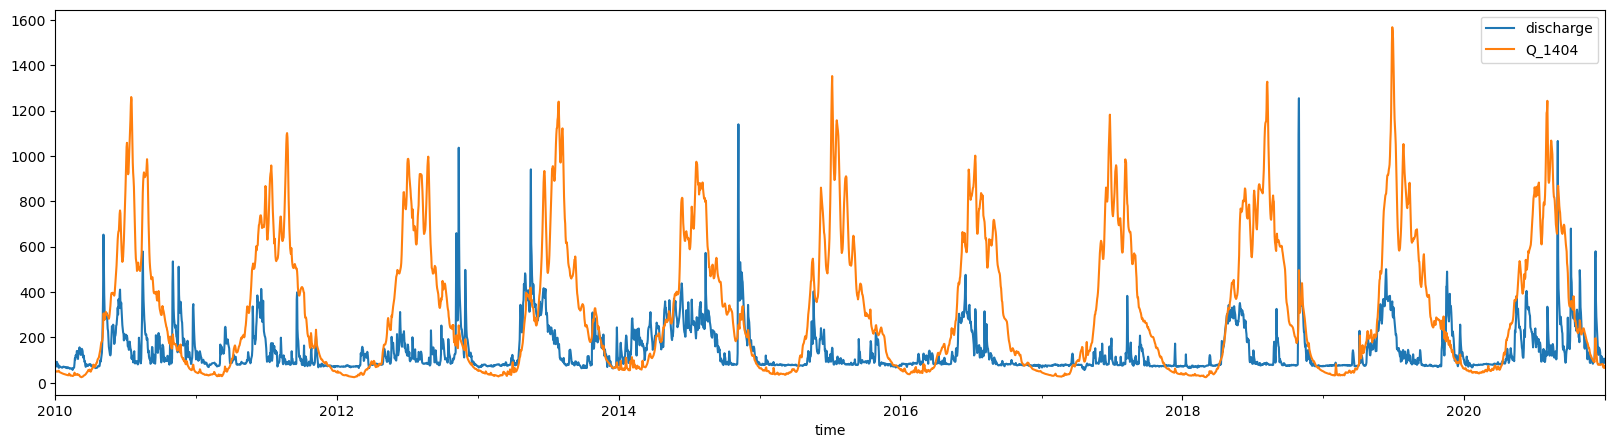

In [896]:
fig,ax = plt.subplots(1,1, figsize=(20,5))
ado_discharge.plot(x="time", ax=ax)
discharge.plot(x="time",ax=ax, label="wflow")

In [897]:
# UNCOMMENT IF NOT LOADING PREPROCESSED INPUTS

#reshape for training

Xd, Xs, Y  = reshape(
                   forcings, 
                   params, 
                   targets
                   )

#Define the 2D missing values mask. Sampling 

missing_mask = np.isnan(params[static_names[0]]).values

# UNCOMMENT TO SAVE
# np.savez_compressed( surrogate_input_path / f"{wflow_model}", Xd=Xd, Xs=Xs, Y=Y, missing_mask = missing_mask)

dynamic:  (40140, 4018, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (40140, 2)  => (GRIDCELL, FEATURE)
target:  (40140, 4018, 1)  => (GRIDCELL, TIME, TARGET)


In [898]:
Y = discharge[f"Q_{outlet_id}"].values

In [823]:
Y = ado_discharge["discharge"].values

In [899]:
Y = np.expand_dims(Y,(0,2))# batch, time, feat

In [900]:
Y = (Y - Y.mean())/ Y.std()

In [901]:
Y.shape

(1, 4018, 1)

In [902]:
intervals = (1, 1) # every n km
train_origin = (0, 0)
val_origin = (1, 1)

spatial_train_sampler = RegularIntervalSampler(intervals = intervals, origin = train_origin)
spatial_val_sampler = RegularIntervalSampler(intervals = intervals, origin = val_origin) 

In [903]:
data2d  = forcings.to_dataarray().transpose("lat","lon", "time", "variable")

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, missing_mask)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, missing_mask)

In [904]:
# _, d_m, d_std = apply_normalization(Xd, type = "spacetime", how ='standard')
# _, s_m, s_std = apply_normalization(Xs, type = "space", how ='standard')

In [905]:
_, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
_, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
#_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

In [906]:
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std)
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std)
#Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std)

In [907]:
Xs = torch.Tensor(Xs)
Xd = torch.Tensor(Xd)
Y = torch.Tensor(Y)

Xs.shape, Xd.shape, Y.shape

(torch.Size([40140, 2]),
 torch.Size([40140, 4018, 3]),
 torch.Size([1, 4018, 1]))

In [908]:
# init datasets
dataset = LSTMDischargeDataset(Xd,Y,Xs)

In [909]:
train_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

In [910]:
train_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = valid_sampler)

In [911]:
model = CustomLSTM(model_params)
model = model.to(device)
model

CustomLSTM(
  (fc0): Linear(in_features=5, out_features=32, bias=True)
  (lstm): LSTM(32, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=1, bias=True)
)

In [912]:
path2models= "./checkpoints" 
if not os.path.exists(path2models):
    os.mkdir(path2models)
    
    
opt = optim.Adam(model.parameters(), lr=1e-2)


loss_fn = RMSELoss()

metric_fn = mse_metric

lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=10)

epochs = 30

params_train={
    "num_epochs": epochs,
    "temporal_sampling_idx_change_with_epoch": True,
    "temporal_sampling_size": temporal_sampling_size,
    "seq_length": seq_length,
    "ts_range": Y.shape[1],
    "optimizer": opt,
    "loss_func": loss_fn,
    "metric_func": metric_fn,
    "train_dl": train_loader, 
    "val_dl": val_loader,
    "lr_scheduler": lr_scheduler,
    "path2weights": f"{path2models}/weights.pt",
    "device":device,
    "target_names": target_names

}

In [ ]:
model, sm_loss_history, sm_metric_history = train_val(model, params_train)

Epoch 0/29, current lr=0.01
Copied best model weights!
train loss: 0.20653559267520905, train metric: {'q_river': 0.08439568}
val loss: 0.5208534598350525, val metric: {'q_river': 0.4425921}
----------
Epoch 1/29, current lr=0.01
Copied best model weights!
train loss: 0.19052965939044952, train metric: {'q_river': 0.07645207}
val loss: 0.3649304509162903, val metric: {'q_river': 0.23747683}
----------
Epoch 2/29, current lr=0.01
train loss: 0.22856633365154266, train metric: {'q_river': 0.10046501}
val loss: 0.7685382962226868, val metric: {'q_river': 0.9075018}
----------
Epoch 3/29, current lr=0.01
train loss: 0.32393619418144226, train metric: {'q_river': 0.20379338}
val loss: 0.5284765362739563, val metric: {'q_river': 0.46390998}
----------
Epoch 4/29, current lr=0.01
train loss: 0.3336014151573181, train metric: {'q_river': 0.19596703}
val loss: 0.4033908247947693, val metric: {'q_river': 0.30235222}
----------
Epoch 5/29, current lr=0.01
train loss: 0.2360420525074005, train met

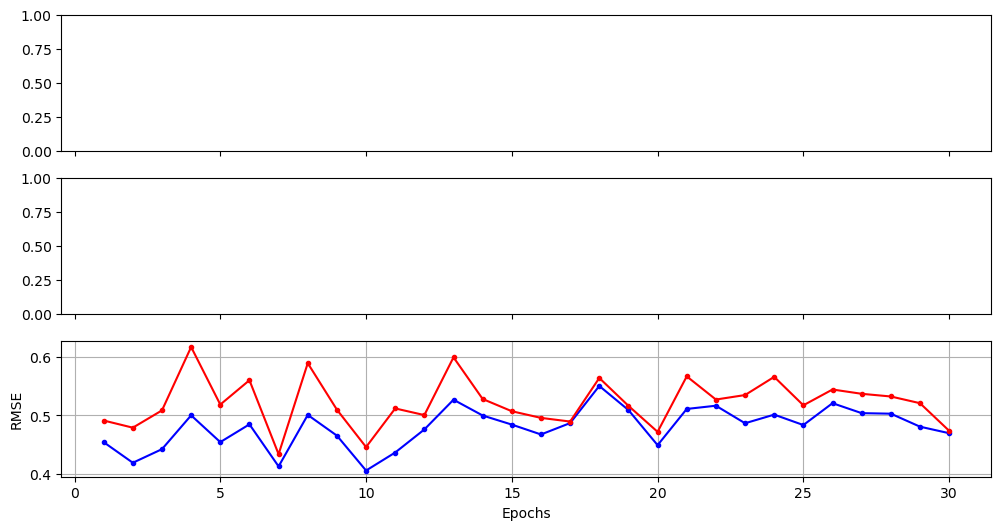

In [866]:
lepochs = list(range(1,params_train["num_epochs"] + 1))

fig, axs = plt.subplots(3, 1, figsize= (12,6), sharex=True)

# axs[0].plot(lepochs, sm_metric_history['train_vwc'], marker='.', linestyle='-', color='b', label='Training')
# axs[0].plot(lepochs, sm_metric_history['val_vwc'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[0].set_ylabel(metric_fn.__name__)
# axs[0].grid(True)
# axs[0].legend(bbox_to_anchor=(1,1))

# axs[1].plot(lepochs, sm_metric_history['train_actevap'], marker='.', linestyle='-', color='b', label='Training')
# axs[1].plot(lepochs, sm_metric_history['val_actevap'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[1].set_ylabel(metric_fn.__name__)
# axs[1].grid(True)

axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['train']], marker='.', linestyle='-', color='b', label='Training')
axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['val']], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel(loss_fn.__name__)
axs[2].grid(True)

In [867]:
torch.cuda.empty_cache()

# predict over the whole spatial domain using the model trained over the subsample
yhat = predict(Xd, Xs, model, spatial_batch_size, device=device)
yhat.shape

lat, lon, time = *forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd.shape[1]
lat*lon ,time

# yhat = (yhat*y_std) + y_m

(40140, 4018)

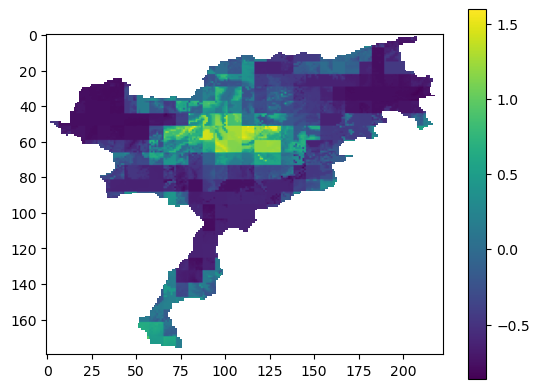

In [868]:
plt.imshow(yhat.reshape(lat,lon,time)[...,304])
plt.colorbar()

In [869]:
from hython.utils import to_xr

In [870]:
ret = to_xr(yhat.reshape(lat,lon,time), coords=targets.coords)

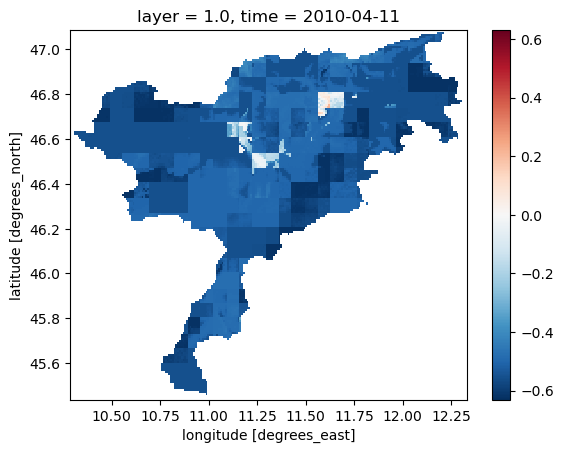

In [871]:
ret.isel(time=100).plot()

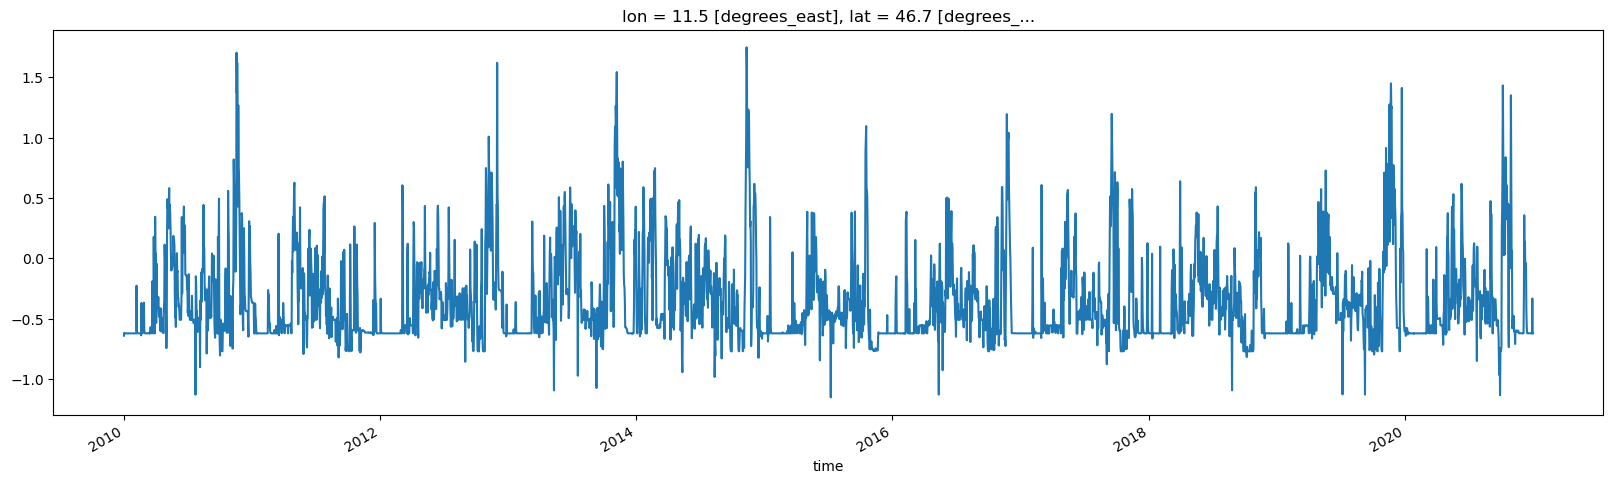

In [873]:
fig, ax = plt.subplots(1,1, figsize=(20,5))
ret.sel(lat = 46.7, lon = 11.5 ,method="nearest").plot(ax=ax)

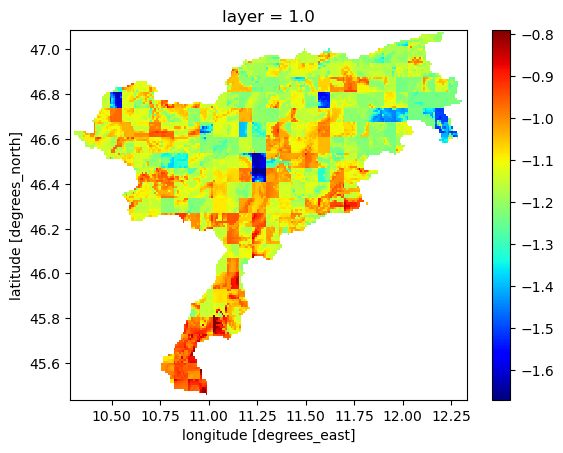

In [874]:
ret.min("time").plot(cmap="jet")

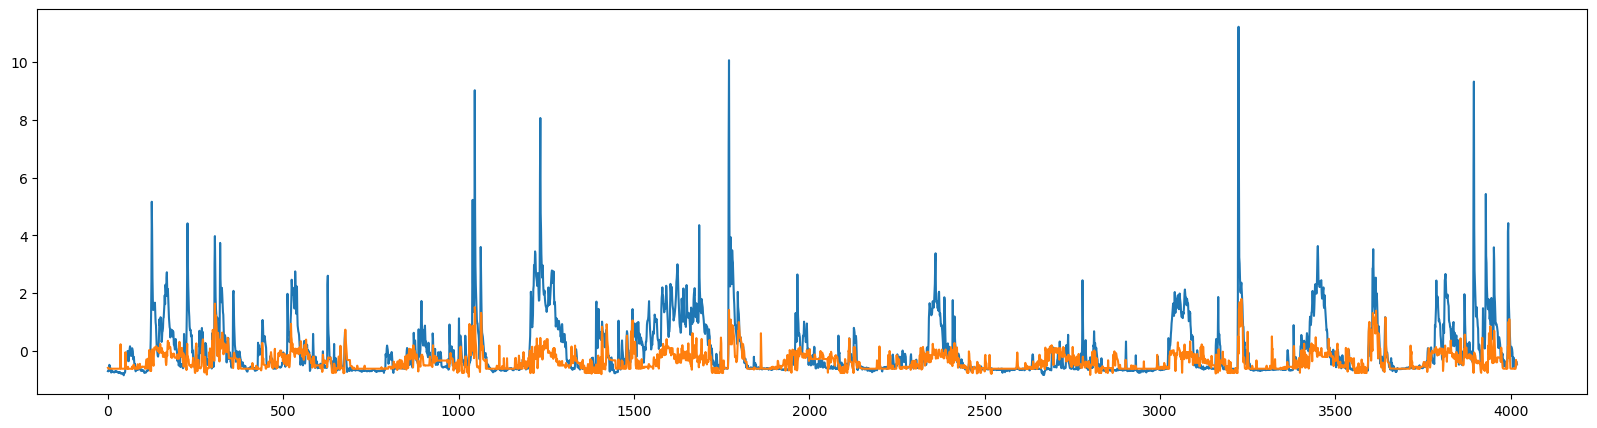

In [875]:
plt.subplots(1,1, figsize=(20,5))
plt.plot(Y.numpy()[0,:,0])
plt.plot(ret.sel(lat= 45.5, lon= 10.9, method="nearest").values)

In [173]:
class SMEP(nn.Module):
   ...:     def __init__(self):
   ...:         super(SMEP, self).__init__()
   ...:         self.distr = nn.Linear(8,2, bias=False)
    
   ...:         self.linear = nn.Linear(2,1, bias=False)
    
   ...:     def forward(self, X):
   ...:         sm_evap = torch.stack([self.distr(time) for time in X ])#;print(sm_evap.shape)
   ...:         #q1 = torch.mean(sm_evap,0)#;print(q1.shape) n batches -> (20,2)
   ...:         #q = self.linear(q1)#;print(q.shape) smet -> (20,1)
   ...:         return sm_evap

In [174]:
class Dis(nn.Module):
    def __init__(self):
        super(Dis, self).__init__()
        self.linear = nn.Linear(2,1, bias=False)
    def forward(self, smet):
        q1 = torch.mean(smet, 0)
        #;print(q1.shape)  #n batches -> (20,2)
        q = self.linear(q1)
        #;print(q.shape) #smet -> (20,1)    
        return q
        

In [175]:
model1 = SMEP()
model2 = Dis()

In [176]:
#q, smet = model(P)

In [177]:
# # Create DataLoader
#train_dataset = TensorDataset(P, Y)

#train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)

In [178]:
import itertools

criterion = nn.MSELoss()
optimizer = optim.Adam(itertools.chain(model1.parameters(), model2.parameters()), lr=0.001)

# Training loop
num_epochs = 1000

qq = []
smsm = []

for epoch in range(num_epochs):
    model1.train()
    model2.train()
    smet_all = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Forward pass
        smet = model1(batch_X)
        smet_all.append(smet)
        #print(batch_y[...,[2]].shape,batch_y[...,[0,1]].shape)
        
        #loss_q = criterion(q, batch_y[[2]])
        #loss_smet = criterion(smet, batch_y[...,[0,1]])

        #loss = loss_q + loss_smet
        # Backward pass
        #loss.backward()

        # Update weights
        #optimizer.step()
    smetall = torch.cat(smet_all)

    q = model2(smetall)
    #print(q)
    #print(train_loader.dataset.tensors[1][...,[2]].shape)
    
    loss_q = criterion(q,train_loader.dataset.y[1][...,[2]])
    loss_smet = criterion(smetall, train_loader.dataset.y[1][...,[0,1]] )

    loss = loss_q + loss_smet

    loss.backward()

    optimizer.step()
    
    #print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

ValueError: too many values to unpack (expected 2)

In [ ]:
def predict(model1, model2, input_data, batch_size=3):
    model1.eval()
    model2.eval()
    
    # with torch.no_grad():
    #     input_tensor = torch.tensor(input_data, dtype=torch.float32)
    #     # Ensure the input tensor has the correct shape (batch_size, input_channels, height, width)
    #     # if len(input_tensor.shape) == 3:
    #     #     input_tensor = input_tensor.unsqueeze(0)
        
    #     smet = model(input_tensor)
    with torch.no_grad():

        SMET = []
        for i in range(0,input_data.shape[0], batch_size):
            
            smet = torch.Tensor(input_data[i:(i+batch_size)])
            
            SMET.append(
                model1(smet)
                )
        smetall = torch.cat(SMET)

        q = model2(smetall)

    return q.numpy(), smetall.numpy()

In [ ]:
pq, psmet = predict(model1, model2, P)

In [ ]:
plt.plot(pq)
plt.plot(Q[0], label = "true")
plt.legend()

In [ ]:
plt.plot(Y[...,[1,2]].numpy()[10], label="orig")
plt.plot(psmet[10])
plt.legend()